#### Libraries Import

In [64]:
#Data manipulation
import pandas as pd
import numpy as np

#Dataset Loading
from pathlib import Path

#for regex
import re

#Encoder (Categorical to Numeric)
from sklearn.preprocessing import LabelEncoder

#for dataset loading
import gc
import os

#using optuna to finetune the parameters 
import optuna

#Preprocessing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import RobustScaler
from imblearn.over_sampling import SMOTE
from sklearn.utils.class_weight import compute_class_weight

# Models
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

#to display progress bar
from tqdm.auto import tqdm

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, regularizers

# Evaluation
from sklearn.metrics import (classification_report, roc_auc_score, 
            accuracy_score, precision_score, recall_score, f1_score, matthews_corrcoef, confusion_matrix,
            ConfusionMatrixDisplay, 
            roc_curve, 
            auc, 
            precision_recall_curve, 
            average_precision_score)

#Visualization
import matplotlib.pyplot as plt
import seaborn as sns


##### Dataset Source

Loading datasets from the sources in chunks to avoid memory crash.

Cross Dataset Generalization
1. Train dataset : CICIDS2017 from Kaggle (chethuhn/network-intrusion-dataset)
2. Test dataset1: CSE-CIC-IDS2018 from Kaggle (solarmainframe/ids-intrusion-csv)
3. Test dataset1: UNSW-NB15 (https://cicresearch.ca//CICDataset/CIC-UNSW/)

##### Loading the datasets

In [2]:
#Column Normalization
def clean_column_names(df):
    """
    Standardize column names across datasets.
    1. Strip whitespace.
    2. Convert to lowercase.
    3. Replace:
        space -> _
        /     -> _
        -     -> _
        .     -> _
    4. Remove duplicate columns.
    5. Remove double underscores.

    Example:
    --------
    ' Flow Duration ' -> flow_duration
    'Dst-Port'        -> dst_port
    """

    df.columns = (
        df.columns.astype(str)
        .str.strip()
        .str.lower()
        .str.replace(" ", "_", regex=False)
        .str.replace("/", "_", regex=False)
        .str.replace("-", "_", regex=False)
        .str.replace(".", "_", regex=False)
    )

    df.columns = df.columns.str.replace("__", "_", regex=False)

    df = df.loc[:, ~df.columns.duplicated()]

    return df

#Optimize memory
def optimize_dtypes(df):
    LABEL_COL = "label"
    SOURCE_COL = "source_file"

    # Handle label safely
    if LABEL_COL in df.columns:
        df[LABEL_COL] = df[LABEL_COL].astype("category")

    # Convert everything else to numeric
    exclude = {LABEL_COL, SOURCE_COL}

    for col in df.columns:
        if col in exclude:
            continue

        df[col] = pd.to_numeric(df[col], errors="coerce")

    # Downcast floats for memory efficiency 
    float_cols = df.select_dtypes(include=["float64"]).columns
    df[float_cols] = df[float_cols].astype("float32")

    # ensure label is still valid
    # (helps catch corruption early in NIDS datasets)
    if LABEL_COL in df.columns:
        df[LABEL_COL] = df[LABEL_COL].cat.add_categories(["UNKNOWN"])
        df[LABEL_COL] = df[LABEL_COL].fillna("UNKNOWN")

    return df

#Processing Chunks
def process_chunk(chunk, source_file):
    chunk["source_file"] = source_file
    chunk = clean_column_names(chunk)
    chunk = optimize_dtypes(chunk)
    return chunk

# CSV to parquet caching
def csv_to_parquet_chunks(
    csv_path,
    cache_dir,
    chunksize=100_000
):
    """
    Convert one CSV file into multiple Parquet chunks to avoid memory(RAM) crash.
    """

    csv_path = Path(csv_path)

    file_stem = csv_path.stem

    print(f"\nProcessing {csv_path.name}")

    try:
        reader = pd.read_csv(
            csv_path,
            chunksize=chunksize,
            low_memory=True,
            encoding="utf-8"
        )

    except UnicodeDecodeError:

        reader = pd.read_csv(
            csv_path,
            chunksize=chunksize,
            low_memory=True,
            encoding="latin-1"
        )

    parquet_files = []

    for idx, chunk in enumerate(reader, start=1):

        parquet_file = (
            cache_dir /
            f"{file_stem}_part_{idx:04d}.parquet"
        )

        if parquet_file.exists():

            print(
                f"  [SKIP] {parquet_file.name}"
            )

            parquet_files.append(str(parquet_file))

            continue

        chunk = process_chunk(
            chunk,
            csv_path.name
        )

        chunk.to_parquet(
            parquet_file,
            index=False
        )

        parquet_files.append(str(parquet_file))

        print(
            f"  [SAVED] "
            f"{parquet_file.name} "
            f"{chunk.shape}"
        )

        del chunk
        gc.collect()

    return parquet_files

#Process whole dataset
def process_folder(
    folder_path,
    dataset_name,
    chunksize=100_000
):

    folder_path = Path(folder_path)

    csv_files = sorted(
        folder_path.glob("*.csv")
    )

    if not csv_files:
        raise FileNotFoundError(
            f"No CSV files found in {folder_path}"
        )

    cache_dir = (
        folder_path /
        "_parquet_cache"
    )

    cache_dir.mkdir(exist_ok=True)

    all_parquet_files = []

    print(
        f"\n[{dataset_name}] "
        f"{len(csv_files)} CSV files found"
    )

    for csv_file in csv_files:

        parquet_files = csv_to_parquet_chunks(
            csv_file,
            cache_dir,
            chunksize
        )

        all_parquet_files.extend(
            parquet_files
        )

    print(
        f"\n[{dataset_name}] "
        f"Generated {len(all_parquet_files)} parquet chunks"
    )

    return all_parquet_files

# Loading data in chunks
def build_dataset_caches(
    train_folder,
    test1_folder,
    test2_folder,
    chunksize=100_000
):
    """
    Build Parquet chunk caches for:

    TRAIN
    TEST_1
    TEST_2

    Returns:
    --------
    train_chunks
    test1_chunks
    test2_chunks

    Each is a list of parquet files.
    """

    train_chunks = process_folder(
        train_folder,
        "TRAIN",
        chunksize
    )

    test1_chunks = process_folder(
        test1_folder,
        "TEST_1",
        chunksize
    )

    test2_chunks = process_folder(
        test2_folder,
        "TEST_2",
        chunksize
    )

    return (
        train_chunks,
        test1_chunks,
        test2_chunks
    )

#Load only the needed ones.
def load_parquet_chunk(parquet_file):
    """
    Load a single parquet chunk.

    for feature engineering or model training.
    """

    return pd.read_parquet(parquet_file)

##### Caching the datasets in chunks for easy loading in the future

In [3]:
train_folder = r"C:/Users/Acer/.cache/kagglehub/datasets/chethuhn/network-intrusion-dataset/versions/1/"
test1_folder = r"C:/Users/Acer/.cache/kagglehub/datasets/solarmainframe/ids-intrusion-csv/versions/1/"
test2_folder = r"E:/gisma modules/dissertation/dataset/unswnb15/"

train_chunks, test1_chunks, test2_chunks = (
    build_dataset_caches(
        train_folder,
        test1_folder,
        test2_folder,
        chunksize=100_000
    )
)

print("\nFinished cache generation.")

print("Train chunks :", len(train_chunks))
print("Test1 chunks :", len(test1_chunks))
print("Test2 chunks :", len(test2_chunks))


[TRAIN] 8 CSV files found

Processing Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv
  [SKIP] Friday-WorkingHours-Afternoon-DDos.pcap_ISCX_part_0001.parquet
  [SKIP] Friday-WorkingHours-Afternoon-DDos.pcap_ISCX_part_0002.parquet
  [SKIP] Friday-WorkingHours-Afternoon-DDos.pcap_ISCX_part_0003.parquet

Processing Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv
  [SKIP] Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX_part_0001.parquet
  [SKIP] Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX_part_0002.parquet
  [SKIP] Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX_part_0003.parquet

Processing Friday-WorkingHours-Morning.pcap_ISCX.csv
  [SKIP] Friday-WorkingHours-Morning.pcap_ISCX_part_0001.parquet
  [SKIP] Friday-WorkingHours-Morning.pcap_ISCX_part_0002.parquet

Processing Monday-WorkingHours.pcap_ISCX.csv
  [SKIP] Monday-WorkingHours.pcap_ISCX_part_0001.parquet
  [SKIP] Monday-WorkingHours.pcap_ISCX_part_0002.parquet
  [SKIP] Monday-WorkingHours.pcap_ISCX_part_0003.parquet
  

C:\Users\Acer\AppData\Local\Temp\ipykernel_10224\4273616412.py:109: DtypeWarning: Columns (0,1,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35,36,37,38,39,40,41,42,43,44,45,46,47,48,49,50,51,52,53,54,55,56,57,58,59,60,61,62,63,64,65,66,67,68,69,70,71,72,73,74,75,76,77,78) have mixed types. Specify dtype option on import or set low_memory=False.
  for idx, chunk in enumerate(reader, start=1):


  [SKIP] 02-16-2018_part_0010.parquet
  [SKIP] 02-16-2018_part_0011.parquet

Processing 02-20-2018.csv
  [SKIP] 02-20-2018_part_0001.parquet
  [SKIP] 02-20-2018_part_0002.parquet
  [SKIP] 02-20-2018_part_0003.parquet
  [SKIP] 02-20-2018_part_0004.parquet
  [SKIP] 02-20-2018_part_0005.parquet
  [SKIP] 02-20-2018_part_0006.parquet
  [SKIP] 02-20-2018_part_0007.parquet
  [SKIP] 02-20-2018_part_0008.parquet
  [SKIP] 02-20-2018_part_0009.parquet
  [SKIP] 02-20-2018_part_0010.parquet
  [SKIP] 02-20-2018_part_0011.parquet
  [SKIP] 02-20-2018_part_0012.parquet
  [SKIP] 02-20-2018_part_0013.parquet
  [SKIP] 02-20-2018_part_0014.parquet
  [SKIP] 02-20-2018_part_0015.parquet
  [SKIP] 02-20-2018_part_0016.parquet
  [SKIP] 02-20-2018_part_0017.parquet
  [SKIP] 02-20-2018_part_0018.parquet
  [SKIP] 02-20-2018_part_0019.parquet
  [SKIP] 02-20-2018_part_0020.parquet
  [SKIP] 02-20-2018_part_0021.parquet
  [SKIP] 02-20-2018_part_0022.parquet
  [SKIP] 02-20-2018_part_0023.parquet
  [SKIP] 02-20-2018_par

C:\Users\Acer\AppData\Local\Temp\ipykernel_10224\4273616412.py:109: DtypeWarning: Columns (0,1,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35,36,37,38,39,40,41,42,43,44,45,46,47,48,49,50,51,52,53,54,55,56,57,58,59,60,61,62,63,64,65,66,67,68,69,70,71,72,73,74,75,76,77,78) have mixed types. Specify dtype option on import or set low_memory=False.
  for idx, chunk in enumerate(reader, start=1):


  [SKIP] 02-28-2018_part_0001.parquet


...

  [SKIP] 02-28-2018_part_0007.parquet

Processing 03-01-2018.csv


C:\Users\Acer\AppData\Local\Temp\ipykernel_10224\4273616412.py:109: DtypeWarning: Columns (0,1,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35,36,37,38,39,40,41,42,43,44,45,46,47,48,49,50,51,52,53,54,55,56,57,58,59,60,61,62,63,64,65,66,67,68,69,70,71,72,73,74,75,76,77,78) have mixed types. Specify dtype option on import or set low_memory=False.
  for idx, chunk in enumerate(reader, start=1):


  [SKIP] 03-01-2018_part_0001.parquet
  [SKIP] 03-01-2018_part_0002.parquet
  [SKIP] 03-01-2018_part_0003.parquet


C:\Users\Acer\AppData\Local\Temp\ipykernel_10224\4273616412.py:109: DtypeWarning: Columns (0,1,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35,36,37,38,39,40,41,42,43,44,45,46,47,48,49,50,51,52,53,54,55,56,57,58,59,60,61,62,63,64,65,66,67,68,69,70,71,72,73,74,75,76,77,78) have mixed types. Specify dtype option on import or set low_memory=False.
  for idx, chunk in enumerate(reader, start=1):


  [SKIP] 03-01-2018_part_0004.parquet

Processing 03-02-2018.csv
  [SKIP] 03-02-2018_part_0001.parquet
  [SKIP] 03-02-2018_part_0002.parquet
  [SKIP] 03-02-2018_part_0003.parquet
  [SKIP] 03-02-2018_part_0004.parquet
  [SKIP] 03-02-2018_part_0005.parquet
  [SKIP] 03-02-2018_part_0006.parquet
  [SKIP] 03-02-2018_part_0007.parquet
  [SKIP] 03-02-2018_part_0008.parquet
  [SKIP] 03-02-2018_part_0009.parquet
  [SKIP] 03-02-2018_part_0010.parquet
  [SKIP] 03-02-2018_part_0011.parquet

[TEST_1] Generated 168 parquet chunks

[TEST_2] 1 CSV files found

Processing CICFlowMeter_out.csv
  [SKIP] CICFlowMeter_out_part_0001.parquet
  [SKIP] CICFlowMeter_out_part_0002.parquet
  [SKIP] CICFlowMeter_out_part_0003.parquet
  [SKIP] CICFlowMeter_out_part_0004.parquet
  [SKIP] CICFlowMeter_out_part_0005.parquet
  [SKIP] CICFlowMeter_out_part_0006.parquet
  [SKIP] CICFlowMeter_out_part_0007.parquet
  [SKIP] CICFlowMeter_out_part_0008.parquet
  [SKIP] CICFlowMeter_out_part_0009.parquet
  [SKIP] CICFlowMeter

##### Concatenating Chunks and reading the datasets with memory optimization.

In [4]:
import pandas as pd
import gc

# Function to concatenate dataset chunks with memory optimization
def concat_chunks(chunk_files, dataset_name):
    df_list = []

    print(f"\nLoading {dataset_name}...")

    for file in chunk_files:

        # Read chunk
        chunk = pd.read_parquet(file)

        # Drop unnecessary column immediately
        if "source_file" in chunk.columns:
            chunk.drop(columns=["source_file"], inplace=True)

        # Downcast integer columns
        int_cols = chunk.select_dtypes(include=["int64"]).columns

        for col in int_cols:
            chunk[col] = pd.to_numeric(
                chunk[col],
                downcast="integer"
            )

        # Force downcast float64 → float32
        float64_cols = chunk.select_dtypes(include=["float64"]).columns
        chunk[float64_cols] = chunk[float64_cols].astype("float32")

        # Downcast label if already encoded otherwise categorical
        if (
            "label" in chunk.columns
            and pd.api.types.is_integer_dtype(chunk["label"])
        ):
            chunk["label"] = pd.to_numeric(
                chunk["label"], downcast="integer"
            )

        print(f"Loaded {file} → {chunk.shape}")

        df_list.append(chunk)

        del chunk
        gc.collect()

    print(f"\nConcatenating {dataset_name}...")

    df = pd.concat(df_list, ignore_index=True)

    del df_list
    gc.collect()

    print(f"\n{dataset_name} details after optimization:")
    print(df.info(memory_usage="deep"))

    return df


print("Loading datasets with memory optimization.")

train_df = concat_chunks(train_chunks, "CICIDS2017 (Train Dataset)")
test1_df = concat_chunks(test1_chunks, "CSE-CIC-IDS2018 (Test Dataset 1)")
test2_df = concat_chunks(test2_chunks, "UNSW-NB15 (Test Dataset 2)")

print("\nDatasets loaded successfully.")

Loading datasets with memory optimization.

Loading CICIDS2017 (Train Dataset)...
Loaded C:\Users\Acer\.cache\kagglehub\datasets\chethuhn\network-intrusion-dataset\versions\1\_parquet_cache\Friday-WorkingHours-Afternoon-DDos.pcap_ISCX_part_0001.parquet → (100000, 79)
Loaded C:\Users\Acer\.cache\kagglehub\datasets\chethuhn\network-intrusion-dataset\versions\1\_parquet_cache\Friday-WorkingHours-Afternoon-DDos.pcap_ISCX_part_0002.parquet → (100000, 79)
Loaded C:\Users\Acer\.cache\kagglehub\datasets\chethuhn\network-intrusion-dataset\versions\1\_parquet_cache\Friday-WorkingHours-Afternoon-DDos.pcap_ISCX_part_0003.parquet → (25745, 79)
Loaded C:\Users\Acer\.cache\kagglehub\datasets\chethuhn\network-intrusion-dataset\versions\1\_parquet_cache\Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX_part_0001.parquet → (100000, 79)
Loaded C:\Users\Acer\.cache\kagglehub\datasets\chethuhn\network-intrusion-dataset\versions\1\_parquet_cache\Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX_part_0002.parq

#### Data Exploration 

In [5]:
print("The shape of train dataset CICIDS2017 is:  \n", train_df.shape)
print("The shape of test dataset1 CSE-CIC-IDS2018 is:  \n", test1_df.shape)
print("The shape of test dataset2 UNSW-NB15 is:  \n", test2_df.shape)

The shape of train dataset CICIDS2017 is:  
 (2830743, 79)
The shape of test dataset1 CSE-CIC-IDS2018 is:  
 (16233002, 84)
The shape of test dataset2 UNSW-NB15 is:  
 (3540241, 84)


In [6]:
print("CICIDS2017 details:  \n")
print(train_df.info())

CICIDS2017 details:  

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2830743 entries, 0 to 2830742
Data columns (total 79 columns):
 #   Column                       Dtype  
---  ------                       -----  
 0   destination_port             int32  
 1   flow_duration                int32  
 2   total_fwd_packets            int32  
 3   total_backward_packets       int32  
 4   total_length_of_fwd_packets  int32  
 5   total_length_of_bwd_packets  int32  
 6   fwd_packet_length_max        int16  
 7   fwd_packet_length_min        int16  
 8   fwd_packet_length_mean       float32
 9   fwd_packet_length_std        float32
 10  bwd_packet_length_max        int16  
 11  bwd_packet_length_min        int16  
 12  bwd_packet_length_mean       float32
 13  bwd_packet_length_std        float32
 14  flow_bytes_s                 float32
 15  flow_packets_s               float32
 16  flow_iat_mean                float32
 17  flow_iat_std                 float32
 18  flow_iat_max       

In [7]:
train_df.head(3)

,destination_port,flow_duration,total_fwd_packets,total_backward_packets,total_length_of_fwd_packets,total_length_of_bwd_packets,fwd_packet_length_max,fwd_packet_length_min,fwd_packet_length_mean,fwd_packet_length_std,...,min_seg_size_forward,active_mean,active_std,active_max,active_min,idle_mean,idle_std,idle_max,idle_min,label
0,54865,3,2,0,12,0,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
1,55054,109,1,1,6,6,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
2,55055,52,1,1,6,6,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN


In [8]:
print("CSE-CIC-IDS2018 test dataset1 details:  \n")
print(test1_df.info())

CSE-CIC-IDS2018 test dataset1 details:  

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16233002 entries, 0 to 16233001
Data columns (total 84 columns):
 #   Column             Dtype  
---  ------             -----  
 0   dst_port           float64
 1   protocol           float32
 2   timestamp          float32
 3   flow_duration      float64
 4   tot_fwd_pkts       float64
 5   tot_bwd_pkts       float64
 6   totlen_fwd_pkts    float64
 7   totlen_bwd_pkts    float64
 8   fwd_pkt_len_max    float64
 9   fwd_pkt_len_min    float32
 10  fwd_pkt_len_mean   float32
 11  fwd_pkt_len_std    float32
 12  bwd_pkt_len_max    float32
 13  bwd_pkt_len_min    float32
 14  bwd_pkt_len_mean   float32
 15  bwd_pkt_len_std    float32
 16  flow_byts_s        float32
 17  flow_pkts_s        float32
 18  flow_iat_mean      float32
 19  flow_iat_std       float32
 20  flow_iat_max       float64
 21  flow_iat_min       float64
 22  fwd_iat_tot        float64
 23  fwd_iat_mean       float32
 24  fwd_ia

In [9]:
test1_df.head(3)

,dst_port,protocol,timestamp,flow_duration,tot_fwd_pkts,tot_bwd_pkts,totlen_fwd_pkts,totlen_bwd_pkts,fwd_pkt_len_max,fwd_pkt_len_min,...,active_min,idle_mean,idle_std,idle_max,idle_min,label,flow_id,src_ip,src_port,dst_ip
0,0.0,0.0,NaN,112641719.0,3.0,0.0,0.0,0.0,0.0,0.0,...,0.0,56320860.0,139.300034,56320958.0,56320761.0,Benign,NaN,NaN,NaN,NaN
1,0.0,0.0,NaN,112641466.0,3.0,0.0,0.0,0.0,0.0,0.0,...,0.0,56320732.0,114.551300,56320814.0,56320652.0,Benign,NaN,NaN,NaN,NaN
2,0.0,0.0,NaN,112638623.0,3.0,0.0,0.0,0.0,0.0,0.0,...,0.0,56319312.0,301.934601,56319525.0,56319098.0,Benign,NaN,NaN,NaN,NaN


In [10]:
print("UNSW-NB15 test dataset2 details:  \n")
print(test2_df.info())

UNSW-NB15 test dataset2 details:  

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3540241 entries, 0 to 3540240
Data columns (total 84 columns):
 #   Column                      Dtype  
---  ------                      -----  
 0   flow_id                     float32
 1   src_ip                      float32
 2   src_port                    int32  
 3   dst_ip                      float32
 4   dst_port                    int32  
 5   protocol                    int8   
 6   timestamp                   float32
 7   flow_duration               int32  
 8   total_fwd_packet            int16  
 9   total_bwd_packets           int16  
 10  total_length_of_fwd_packet  float32
 11  total_length_of_bwd_packet  float32
 12  fwd_packet_length_max       float32
 13  fwd_packet_length_min       float32
 14  fwd_packet_length_mean      float32
 15  fwd_packet_length_std       float32
 16  bwd_packet_length_max       float32
 17  bwd_packet_length_min       float32
 18  bwd_packet_length_mean    

In [11]:
test2_df.head(3)

,flow_id,src_ip,src_port,dst_ip,dst_port,protocol,timestamp,flow_duration,total_fwd_packet,total_bwd_packets,...,fwd_seg_size_min,active_mean,active_std,active_max,active_min,idle_mean,idle_std,idle_max,idle_min,label
0,NaN,NaN,23357,NaN,80,6,NaN,214392,9,21,...,20,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Exploits
1,NaN,NaN,13284,NaN,80,6,NaN,2376792,9,3,...,20,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Reconnaissance
2,NaN,NaN,13792,NaN,5555,6,NaN,131350,10,3,...,20,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Exploits


#### Data Pre-Processing

Since the column names of all the 3 datasets are different, we will rename the columns of train and test2 datasets as per the names of test1 and only take the common features from all the datasets for further analysis

In [12]:
# function to apply mapping
def apply_column_mapping(train_df, test1_df, test2_df):
    """
    - function to rename the columns of  datasets as per the names of the columns of CSE-CIC-IDS2018 (test1 dataset) without dropping any columns and changing the datatype.
    """

    #train columns mapped to test1 columns
    train_map = {
        "destination_port": "dst_port",
        "total_fwd_packets": "tot_fwd_pkts",
        "total_backward_packets": "tot_bwd_pkts",
        "total_length_of_fwd_packets": "totlen_fwd_pkts",
        "total_length_of_bwd_packets": "totlen_bwd_pkts",
        "fwd_packet_length_max": "fwd_pkt_len_max",
        "fwd_packet_length_min": "fwd_pkt_len_min",
        "fwd_packet_length_mean": "fwd_pkt_len_mean",
        "fwd_packet_length_std": "fwd_pkt_len_std",
        "bwd_packet_length_max": "bwd_pkt_len_max",
        "bwd_packet_length_min": "bwd_pkt_len_min",
        "bwd_packet_length_mean": "bwd_pkt_len_mean",
        "bwd_packet_length_std": "bwd_pkt_len_std",
        "flow_bytes_s": "flow_byts_s",
        "flow_packets_s": "flow_pkts_s",
        "fwd_iat_total": "fwd_iat_tot",
        "bwd_iat_total": "bwd_iat_tot",
        "fwd_header_length": "fwd_header_len",
        "bwd_header_length": "bwd_header_len",
        "min_packet_length": "pkt_len_min",
        "max_packet_length": "pkt_len_max",
        "packet_length_mean": "pkt_len_mean",
        "packet_length_std": "pkt_len_std",
        "packet_length_variance": "pkt_len_var",
        "fin_flag_count": "fin_flag_cnt",
        "ece_flag_count": "ece_flag_cnt",
        "average_packet_size": "pkt_size_avg",
        "avg_fwd_segment_size": "fwd_seg_size_avg",
        "avg_bwd_segment_size": "bwd_seg_size_avg",
    }
    
    #test2 columns mapped to test1 columns
    test2_map = {
        "total_fwd_packet": "tot_fwd_pkts",
        "total_bwd_packets": "tot_bwd_pkts",
        "total_length_of_fwd_packet": "totlen_fwd_pkts",
        "total_length_of_bwd_packet": "totlen_bwd_pkts",
        "fwd_packet_length_max": "fwd_pkt_len_max",
        "fwd_packet_length_min": "fwd_pkt_len_min",
        "fwd_packet_length_mean": "fwd_pkt_len_mean",
        "fwd_packet_length_std": "fwd_pkt_len_std",
        "bwd_packet_length_max": "bwd_pkt_len_max",
        "bwd_packet_length_min": "bwd_pkt_len_min",
        "bwd_packet_length_mean": "bwd_pkt_len_mean",
        "bwd_packet_length_std": "bwd_pkt_len_std",
        "flow_bytes_s": "flow_byts_s",
        "flow_packets_s": "flow_pkts_s",
        "fwd_iat_total": "fwd_iat_tot",
        "bwd_iat_total": "bwd_iat_tot",
        "fwd_header_length": "fwd_header_len",
        "bwd_header_length": "bwd_header_len",
        "packet_length_min": "pkt_len_min",
        "packet_length_max": "pkt_len_max",
        "packet_length_mean": "pkt_len_mean",
        "packet_length_std": "pkt_len_std",
        "packet_length_variance": "pkt_len_var",
        "fin_flag_count": "fin_flag_cnt",
        "ece_flag_count": "ece_flag_cnt",
        "average_packet_size": "pkt_size_avg",
        "fwd_segment_size_avg": "fwd_seg_size_avg",
        "bwd_segment_size_avg": "bwd_seg_size_avg",
    }

    # Apply renaming function
    train_df.rename(columns=train_map, inplace=True)
    test2_df.rename(columns=test2_map, inplace=True)

    return train_df, test1_df, test2_df

#Apply column mapping  
train_df, test1_df, test2_df = apply_column_mapping(train_df, test1_df, test2_df)

##### Data shape Before Handling Infinities, NaNs and Removing Duplicates

In [13]:
print("\nData Shape Before Cleaning:")
print("CICIDS2017 Train dataset :", train_df.shape)
print("CSE-CIC-IDS2018 Test1 dataset :", test1_df.shape)
print("UNSW-NB15 Test2 dataset :", test2_df.shape)


Data Shape Before Cleaning:
CICIDS2017 Train dataset : (2830743, 79)
CSE-CIC-IDS2018 Test1 dataset : (16233002, 84)
UNSW-NB15 Test2 dataset : (3540241, 84)


##### Attacks Comparison Before Handling Infinities, NaNs and Removing Duplicates

In [14]:
# Function to clean the label column
def clean_labels(df):
    df["label"] = df["label"].str.strip().str.lower()
    return df

# Apply to each dataset
train_df = clean_labels(train_df)
test1_df = clean_labels(test1_df)
test2_df = clean_labels(test2_df)

# Count attacks in each dataset
train_counts = train_df["label"].value_counts().sort_index()
test1_counts = test1_df["label"].value_counts().sort_index()
test2_counts = test2_df["label"].value_counts().sort_index()

# Combine into one comparison table
attack_counts_df = pd.concat(
    [train_counts, test1_counts, test2_counts],
    axis=1
)

attack_counts_df.columns = ["CICIDS2017 (Train)", "CSE-CIC-IDS2018 (Test1)", "UNSW-NB15 (Test2)"]
attack_counts_df = attack_counts_df.fillna(0).astype(int)

print("Attack Counts After Cleaning Labels:")
display(attack_counts_df)

Attack Counts After Cleaning Labels:


,CICIDS2017 (Train),CSE-CIC-IDS2018 (Test1),UNSW-NB15 (Test2)
label,,,
benign,2273097,13484708,3450658
bot,1966,286191,0
ddos,128027,0,0
dos goldeneye,10293,0,0
dos hulk,231073,0,0
dos slowhttptest,5499,0,0
dos slowloris,5796,0,0
ftp-patator,7938,0,0
heartbleed,11,0,0


##### Handling Infinities, NaNs and Removing Duplicates

We will first remove the exact duplicates and then remove the irrelevant columns. If we remove the irrelevant columns first, then around 30% of the data will be deleted from all of the datasets.

In [15]:
# Function to clean the datasets
def clean_nids_df(df, name):

    print(f"\nCleaning {name}...")

    # Remove duplicate columns if any 
    df = df.loc[:, ~df.columns.duplicated()]

    # Replace infinities with NaN
    df.replace([np.inf, -np.inf], np.nan, inplace=True)

    # Fill missing values with median due to skewness/class imbalance
    df.fillna(df.median(numeric_only=True), inplace=True)

    # Count duplicate rows
    dup_count = df.duplicated().sum()
    print(f"[{name}] Duplicate rows found: {dup_count:,}")

    # Remove duplicate rows
    df.drop_duplicates(inplace=True)

    # Reset index
    df.reset_index(drop=True, inplace=True)

    print(f"[{name}] Shape after cleaning: {df.shape}")

    gc.collect()

    return df


print("Cleaning the datasets...")

train_df = clean_nids_df(train_df, "CICIDS2017")
test1_df = clean_nids_df(test1_df, "CSE-CIC-IDS2018")
test2_df = clean_nids_df(test2_df, "UNSW-NB15")

print("\nFinal Shapes")
print("CICIDS2017 Train dataset :", train_df.shape)
print("CSE-CIC-IDS2018 Test1 dataset :", test1_df.shape)
print("UNSW-NB15 Test2 dataset :", test2_df.shape)

Cleaning the datasets...

Cleaning CICIDS2017...
[CICIDS2017] Duplicate rows found: 330,995
[CICIDS2017] Shape after cleaning: (2499748, 79)

Cleaning CSE-CIC-IDS2018...
[CSE-CIC-IDS2018] Duplicate rows found: 2,683,410
[CSE-CIC-IDS2018] Shape after cleaning: (13549592, 84)

Cleaning UNSW-NB15...
[UNSW-NB15] Duplicate rows found: 61,608
[UNSW-NB15] Shape after cleaning: (3478633, 84)

Final Shapes
CICIDS2017 Train dataset : (2499748, 79)
CSE-CIC-IDS2018 Test1 dataset : (13549592, 84)
UNSW-NB15 Test2 dataset : (3478633, 84)


##### Saving the cleaned datasets so that we don't have to re-run everything again.

##### Saving in chunks

In [16]:
import os
import math

def save_parquet_chunks(df, output_dir, prefix, chunk_size=500_000):
    """
    Save a DataFrame into multiple Parquet files.

    Parameters
    ----------
    df : pandas.DataFrame
    output_dir : str
        Folder to save the chunks.
    prefix : str
        Prefix for chunk filenames.
    chunk_size : int
        Number of rows per chunk.
    """
    os.makedirs(output_dir, exist_ok=True)

    n_chunks = math.ceil(len(df) / chunk_size)

    for i in range(n_chunks):
        start = i * chunk_size
        end = min((i + 1) * chunk_size, len(df))

        chunk = df.iloc[start:end]

        filename = os.path.join(
            output_dir,
            f"{prefix}_part_{i+1:03d}.parquet"
        )

        chunk.to_parquet(filename, index=False)

        print(f"Saved chunk {i+1}/{n_chunks}: {filename} ({len(chunk):,} rows)")

    print(f"\nFinished saving {n_chunks} chunks.")

save_dir = "processed_datasets_chunked_1"

# CICIDS2017
save_parquet_chunks(
    train_df,
    save_dir,
    "CICIDS2017_train",
    chunk_size=500000
)

# CSE-CIC-IDS2018
save_parquet_chunks(
    test1_df,
    save_dir,
    "CSE_CIC_IDS2018_test1",
    chunk_size=500000
)

# UNSW-NB15
save_parquet_chunks(
    test2_df,
    save_dir,
    "UNSW_NB15_test2",
    chunk_size=500000
)

Saved chunk 1/5: processed_datasets_chunked_1\CICIDS2017_train_part_001.parquet (500,000 rows)
Saved chunk 2/5: processed_datasets_chunked_1\CICIDS2017_train_part_002.parquet (500,000 rows)
Saved chunk 3/5: processed_datasets_chunked_1\CICIDS2017_train_part_003.parquet (500,000 rows)
Saved chunk 4/5: processed_datasets_chunked_1\CICIDS2017_train_part_004.parquet (500,000 rows)
Saved chunk 5/5: processed_datasets_chunked_1\CICIDS2017_train_part_005.parquet (499,748 rows)

Finished saving 5 chunks.
Saved chunk 1/28: processed_datasets_chunked_1\CSE_CIC_IDS2018_test1_part_001.parquet (500,000 rows)
Saved chunk 2/28: processed_datasets_chunked_1\CSE_CIC_IDS2018_test1_part_002.parquet (500,000 rows)
Saved chunk 3/28: processed_datasets_chunked_1\CSE_CIC_IDS2018_test1_part_003.parquet (500,000 rows)
Saved chunk 4/28: processed_datasets_chunked_1\CSE_CIC_IDS2018_test1_part_004.parquet (500,000 rows)
Saved chunk 5/28: processed_datasets_chunked_1\CSE_CIC_IDS2018_test1_part_005.parquet (500,000

#### Exploratory Data Analysis

##### Attacks Comparison After Handling Infinities, NaNs and Removing Duplicates

In [17]:
# Count attacks in each dataset after Handling Infinities, NaNs and Removing Duplicates
train_counts = train_df["label"].value_counts().sort_index()
test1_counts = test1_df["label"].value_counts().sort_index()
test2_counts = test2_df["label"].value_counts().sort_index()

# Combine into one comparison table
attack_counts_df = pd.concat(
    [train_counts, test1_counts, test2_counts],
    axis=1
)

attack_counts_df.columns = ["CICIDS2017 (Train)", "CSE-CIC-IDS2018 (Test1)", "UNSW-NB15 (Test2)"]
attack_counts_df = attack_counts_df.fillna(0).astype(int)

print("Attack Counts After Handling Infinities, NaNs and Removing Duplicates:")
display(attack_counts_df)

Attack Counts After Handling Infinities, NaNs and Removing Duplicates:


,CICIDS2017 (Train),CSE-CIC-IDS2018 (Test1),UNSW-NB15 (Test2)
label,,,
benign,2073870,12196127,3389125
bot,1953,144535,0
ddos,128016,0,0
dos goldeneye,10286,0,0
dos hulk,172849,0,0
dos slowhttptest,5228,0,0
dos slowloris,5385,0,0
ftp-patator,5933,0,0
heartbleed,11,0,0


In [18]:
print(train_df.columns.equals(test1_df.columns))
print(train_df.columns.equals(test2_df.columns))

False
False


##### Taking only the common columns from the 3 datasets

In [19]:
#Find common columns
# Preserve train_df column order

common_cols = [
    col for col in train_df.columns
    if col in test1_df.columns and col in test2_df.columns
]

#forcing "Label"

if "label" not in common_cols:
    common_cols.append("label")

#Align datasets

train_df = train_df.loc[:, common_cols]
test1_df = test1_df.loc[:, common_cols]
test2_df = test2_df.loc[:, common_cols]

gc.collect()

#Verification of "Label" column
for name, df in [
    ("CICIDS2017", train_df),
    ("CSE-CIC-IDS2018", test1_df),
    ("UNSW-NB15", test2_df)
]:
    print(f"\n{name}")
    print("Shape:", df.shape)
    print("Label nulls:", df["label"].isna().sum())
    print("Unique labels:", df["label"].nunique(dropna=True))


#Print summary
print("\nFinal common columns:", len(common_cols))
print("Final shape of CICIDS2017 :", train_df.shape)
print("Final shape of CSE-CIC-IDS2018:", test1_df.shape)
print("Final shape of UNSW-NB15:", test2_df.shape)


CICIDS2017
Shape: (2499748, 56)
Label nulls: 0
Unique labels: 15

CSE-CIC-IDS2018
Shape: (13549592, 56)
Label nulls: 0
Unique labels: 16

UNSW-NB15
Shape: (3478633, 56)
Label nulls: 0
Unique labels: 10

Final common columns: 56
Final shape of CICIDS2017 : (2499748, 56)
Final shape of CSE-CIC-IDS2018: (13549592, 56)
Final shape of UNSW-NB15: (3478633, 56)


In [20]:
print(train_df.columns.equals(test1_df.columns))
print(train_df.columns.equals(test2_df.columns))

True
True


##### Removing bad rows (specifically where the attack is termed as 'label')

In [21]:
test1_df[test1_df["label"] == "Label"]

,dst_port,flow_duration,tot_fwd_pkts,tot_bwd_pkts,totlen_fwd_pkts,totlen_bwd_pkts,fwd_pkt_len_max,fwd_pkt_len_min,fwd_pkt_len_mean,fwd_pkt_len_std,...,bwd_seg_size_avg,active_mean,active_std,active_max,active_min,idle_mean,idle_std,idle_max,idle_min,label


In [22]:
def remove_bad_rows(df):
    df = df[df["label"].str.lower() != "label"]
    return df
    
train_df = remove_bad_rows(train_df)
test1_df = remove_bad_rows(test1_df)
test2_df = remove_bad_rows(test2_df)

##### Mapping attacks

In [23]:
#Regex mapping for attacks

def map_label(label):
    label = str(label).strip().lower()

    # ---------------- BENIGN ----------------
    if re.match(r"^benign", label):
        return "BENIGN"

    # ---------------- Begins with DDoS (STRICT PREFIX) ----------------
    if re.match(r"^ddos", label) or re.search(r"hoic|loic", label):
        return "DDoS"

    # ---------------- Begins with DoS (STRICT PREFIX) ----------------
    if re.match(r"^dos", label):
        return "DoS"

     # ---------------- DoS ----------------
    if re.search(r"generic", label):
        return "DoS"

    # ---------------- Web Attacks ----------------
    if re.search(r"sql injection|xss|web attack", label):
        return "WebAttack"

    # ---------------- Brute Force ----------------
    if re.search(r"brute|brute force|patator|ftp|ssh", label):
        return "BruteForce"

    # ---------------- Bot ----------------
    if re.search(r"^bot\b", label):
        return "Bot"

    # ---------------- PortScan ----------------
    if re.search(r"portscan|scan|reconnaissance", label):
        return "PortScan"

    # ---------------- Infiltration / Exploits ----------------
    if re.search(r"infi(?:l|ltration)|backdoor|shellcode|worm|exploi(?:t|ts)|heartbleed|fuz(?:z|zers)|analysis|worms", label):
        return "Infiltration"

    return "OtherAttack"

    
#Striping the values in "label" column

def clean_labels(df):
    df["label"] = df["label"].astype(str).str.strip()
    return df

#Mapping function
def apply_mapping(df):
    df["label"] = df["label"].apply(map_label)
    return df

#Binary label creation (0= benign, 1 = Attack)
def add_binary_label(df):
    df["binary_label"] = (df["label"] != "BENIGN").astype(int)
    return df


#Multi Class labeling using Encoder
def encode_multiclass(train_df, test1_df, test2_df):
    le = LabelEncoder()

    train_df["multi_label"] = le.fit_transform(train_df["label"])
    test1_df["multi_label"] = le.transform(test1_df["label"])
    test2_df["multi_label"] = le.transform(test2_df["label"])

    return train_df, test1_df, test2_df, le

#Main pipeline for datasets processing
def process_datasets(train_df, test1_df, test2_df):

    # Step 1: clean
    train_df = clean_labels(train_df)
    test1_df = clean_labels(test1_df)
    test2_df = clean_labels(test2_df)

    # Step 2: map
    train_df = apply_mapping(train_df)
    test1_df = apply_mapping(test1_df)
    test2_df = apply_mapping(test2_df)

    # Step 3: binary
    train_df = add_binary_label(train_df)
    test1_df = add_binary_label(test1_df)
    test2_df = add_binary_label(test2_df)

    # Step 4: encode multi-class
    train_df, test1_df, test2_df, le = encode_multiclass(
        train_df, test1_df, test2_df
    )

    return train_df, test1_df, test2_df, le


#Run main pipeline
train_df, test1_df, test2_df, label_encoder = process_datasets(train_df, test1_df, test2_df)

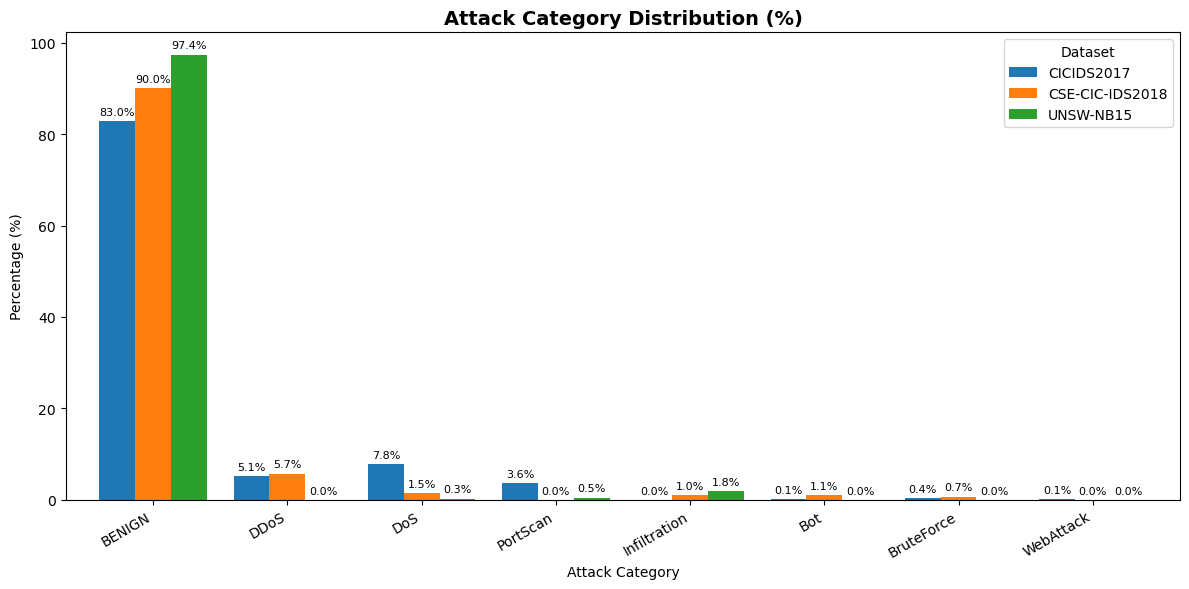

In [24]:
# Plot attack category distribution
def plot_attack_distribution(train_df, test1_df, test2_df):

    # Percentage distribution
    train_pct = train_df["label"].value_counts(normalize=True).mul(100)
    test1_pct = test1_df["label"].value_counts(normalize=True).mul(100)
    test2_pct = test2_df["label"].value_counts(normalize=True).mul(100)

    # Combine into one DataFrame
    dist = pd.concat(
        [train_pct, test1_pct, test2_pct],
        axis=1
    )

    dist.columns = [
        "CICIDS2017",
        "CSE-CIC-IDS2018",
        "UNSW-NB15"
    ]

    # Replace missing attack categories with 0%
    dist = dist.fillna(0)

    # Sort categories by overall percentage (descending)
    dist["Total"] = dist.sum(axis=1)
    dist = dist.sort_values("Total", ascending=False)
    dist = dist.drop(columns="Total")

    # Plot
    ax = dist.plot(
        kind="bar",
        figsize=(12,6),
        width=0.8
    )

    ax.set_title("Attack Category Distribution (%)", fontsize=14, weight="bold")
    ax.set_xlabel("Attack Category")
    ax.set_ylabel("Percentage (%)")
    ax.legend(title="Dataset")
    plt.xticks(rotation=30, ha="right")

    # Percentage labels above bars
    for container in ax.containers:
        ax.bar_label(
            container,
            fmt="%.1f%%",
            fontsize=8,
            padding=3
        )

    plt.tight_layout()
    plt.show()


# Plot
plot_attack_distribution(
    train_df,
    test1_df,
    test2_df
)

##### Counts After Mapping Attacks

In [25]:
# Count attacks in each dataset after Handling Infinities, NaNs and Removing Duplicates
train_counts = train_df["label"].value_counts().sort_index()
test1_counts = test1_df["label"].value_counts().sort_index()
test2_counts = test2_df["label"].value_counts().sort_index()

# Combine into one comparison table
attack_counts_df = pd.concat(
    [train_counts, test1_counts, test2_counts],
    axis=1
)

attack_counts_df.columns = ["CICIDS2017 (Train)", "CSE-CIC-IDS2018 (Test1)", "UNSW-NB15 (Test2)"]
attack_counts_df = attack_counts_df.fillna(0).astype(int)

print("Attack Counts After Mapping")
display(attack_counts_df)

Attack Counts After Mapping


,CICIDS2017 (Train),CSE-CIC-IDS2018 (Test1),UNSW-NB15 (Test2)
label,,,
BENIGN,2073870,12196127,3389125
Bot,1953,144535,0
BruteForce,9152,94655,0
DDoS,128016,776782,0
DoS,193748,196568,9064
Infiltration,47,140612,63734
PortScan,90819,0,16710
WebAttack,2143,312,0


##### Saving the newly formed datasets so that we don't have to re-run everything again.

In [26]:
import os
import math

def save_parquet_chunks(df, output_dir, prefix, chunk_size=500_000):
    """
    Save a DataFrame into multiple Parquet files.

    Parameters
    ----------
    df : pandas.DataFrame
    output_dir : str
        Folder to save the chunks.
    prefix : str
        Prefix for chunk filenames.
    chunk_size : int
        Number of rows per chunk.
    """
    os.makedirs(output_dir, exist_ok=True)

    n_chunks = math.ceil(len(df) / chunk_size)

    for i in range(n_chunks):
        start = i * chunk_size
        end = min((i + 1) * chunk_size, len(df))

        chunk = df.iloc[start:end]

        filename = os.path.join(
            output_dir,
            f"{prefix}_part_{i+1:03d}.parquet"
        )

        chunk.to_parquet(filename, index=False)

        print(f"Saved chunk {i+1}/{n_chunks}: {filename} ({len(chunk):,} rows)")

    print(f"\nFinished saving {n_chunks} chunks.")

save_dir = "processed_datasets_chunked_attacks_mapped1"

# CICIDS2017
save_parquet_chunks(
    train_df,
    save_dir,
    "CICIDS2017_train",
    chunk_size=500_000
)

# CSE-CIC-IDS2018
save_parquet_chunks(
    test1_df,
    save_dir,
    "CSE_CIC_IDS2018_test1",
    chunk_size=500_000
)

# UNSW-NB15
save_parquet_chunks(
    test2_df,
    save_dir,
    "UNSW_NB15_test2",
    chunk_size=500_000
)

Saved chunk 1/5: processed_datasets_chunked_attacks_mapped1\CICIDS2017_train_part_001.parquet (500,000 rows)
Saved chunk 2/5: processed_datasets_chunked_attacks_mapped1\CICIDS2017_train_part_002.parquet (500,000 rows)
Saved chunk 3/5: processed_datasets_chunked_attacks_mapped1\CICIDS2017_train_part_003.parquet (500,000 rows)
Saved chunk 4/5: processed_datasets_chunked_attacks_mapped1\CICIDS2017_train_part_004.parquet (500,000 rows)
Saved chunk 5/5: processed_datasets_chunked_attacks_mapped1\CICIDS2017_train_part_005.parquet (499,748 rows)

Finished saving 5 chunks.
Saved chunk 1/28: processed_datasets_chunked_attacks_mapped1\CSE_CIC_IDS2018_test1_part_001.parquet (500,000 rows)
Saved chunk 2/28: processed_datasets_chunked_attacks_mapped1\CSE_CIC_IDS2018_test1_part_002.parquet (500,000 rows)
Saved chunk 3/28: processed_datasets_chunked_attacks_mapped1\CSE_CIC_IDS2018_test1_part_003.parquet (500,000 rows)
Saved chunk 4/28: processed_datasets_chunked_attacks_mapped1\CSE_CIC_IDS2018_test1_

##### Correlation Heatmap of CICIDS2017

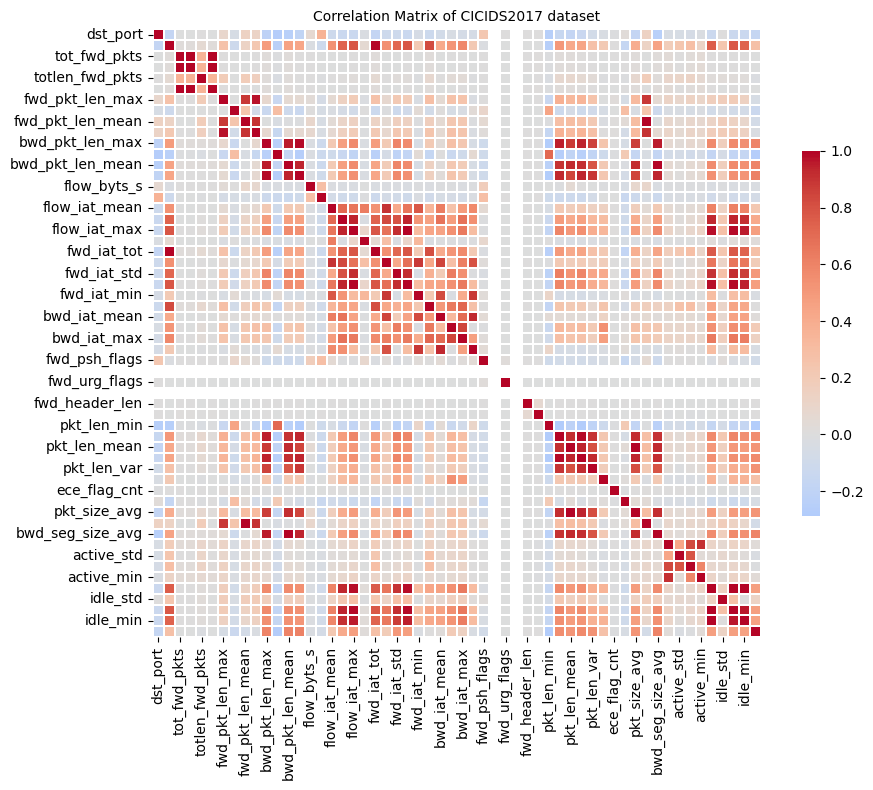

In [27]:
# Exclude target columns
corr_df = train_df.drop(
    columns=["label", "multi_label"], #using binary_label instead of label since it has been mapped to numeric data type.
    errors="ignore"
)

# Keep only numeric columns
corr_df = corr_df.select_dtypes(include=["number"])

# Correlation matrix
corr_matrix = corr_df.corr()

# Plot
plt.figure(figsize=(10, 8))

sns.heatmap(
    corr_matrix,
    cmap="coolwarm",
    center=0,
    square=True,
    linewidths=0.2,
    cbar_kws={"shrink": 0.6}
)

plt.title("Correlation Matrix of CICIDS2017 dataset", fontsize=10)
plt.tight_layout()
plt.show()

##### Correlation Heatmap of CSE-CIC-IDS2018

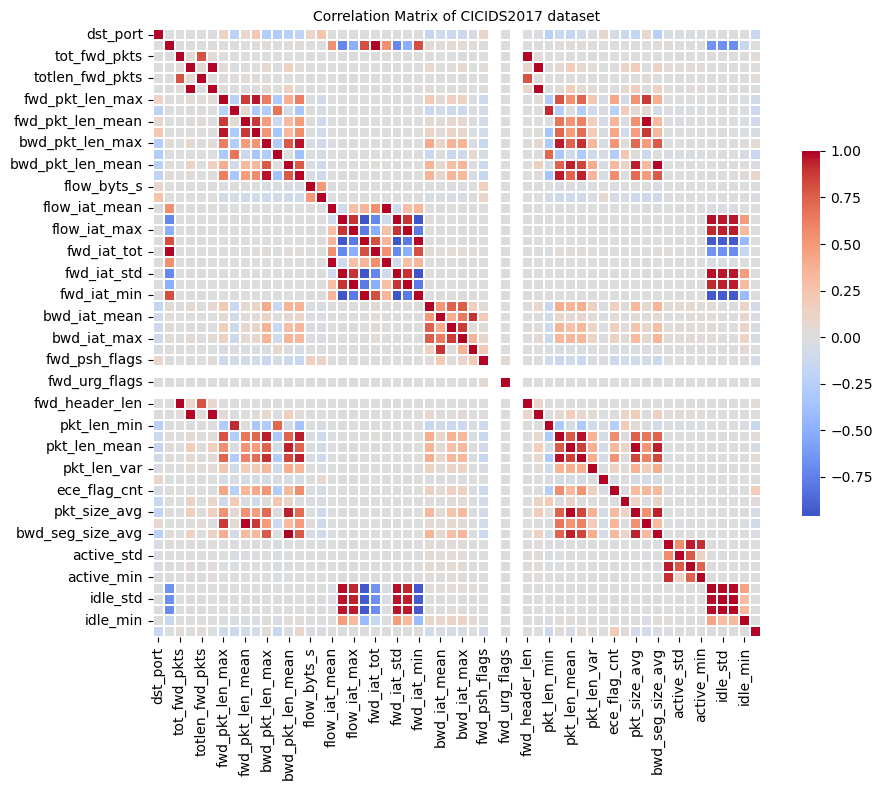

In [28]:
# Exclude target columns
corr_df = test1_df.drop(
    columns=["label", "multi_label"], #using binary_label instead of label since it has been mapped to numeric data type.
    errors="ignore"
)

# Keep only numeric columns
corr_df = corr_df.select_dtypes(include=["number"])

# Correlation matrix
corr_matrix = corr_df.corr()

# Plot
plt.figure(figsize=(10, 8))

sns.heatmap(
    corr_matrix,
    cmap="coolwarm",
    center=0,
    square=True,
    linewidths=0.2,
    cbar_kws={"shrink": 0.6}
)

plt.title("Correlation Matrix of CICIDS2017 dataset", fontsize=10)
plt.tight_layout()
plt.show()

##### Correlation Heatmap of UNSW-NB15

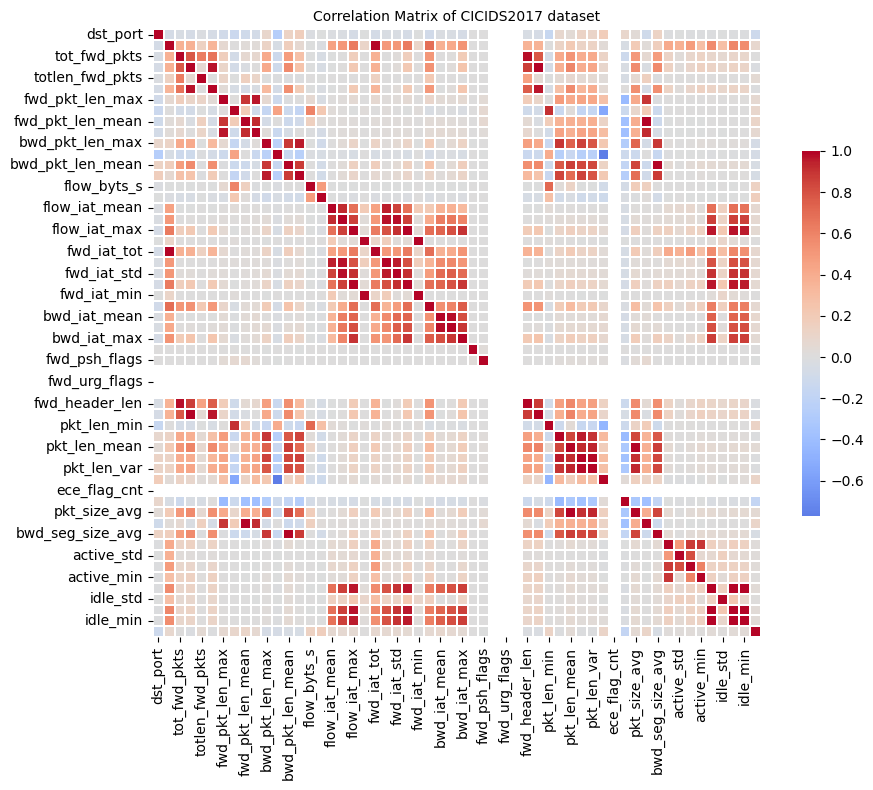

In [29]:
# Exclude target columns
corr_df = test2_df.drop(
    columns=["label", "multi_label"], #using binary_label instead of label since it has been mapped to numeric data type.
    errors="ignore"
)

# Keep only numeric columns
corr_df = corr_df.select_dtypes(include=["number"])

# Correlation matrix
corr_matrix = corr_df.corr()

# Plot
plt.figure(figsize=(10, 8))

sns.heatmap(
    corr_matrix,
    cmap="coolwarm",
    center=0,
    square=True,
    linewidths=0.2,
    cbar_kws={"shrink": 0.6}
)

plt.title("Correlation Matrix of CICIDS2017 dataset", fontsize=10)
plt.tight_layout()
plt.show()

##### Skewness Graph of CICIDS2017


Total Features: 55
Need Transformation: 53
['fwd_header_len', 'totlen_fwd_pkts', 'bwd_header_len', 'tot_bwd_pkts', 'tot_fwd_pkts', 'totlen_bwd_pkts', 'fwd_urg_flags', 'ece_flag_cnt', 'flow_byts_s', 'active_min', 'active_std', 'active_mean', 'flow_iat_min', 'active_max', 'fwd_pkt_len_min', 'down_up_ratio', 'pkt_len_min', 'fwd_pkt_len_std', 'idle_std', 'bwd_iat_min', 'fwd_pkt_len_max', 'fwd_iat_min', 'fwd_pkt_len_mean', 'fwd_seg_size_avg', 'flow_iat_mean', 'bwd_iat_mean', 'flow_pkts_s', 'fwd_iat_mean', 'bwd_iat_std', 'fin_flag_cnt', 'pkt_len_var', 'bwd_pkt_len_min', 'fwd_psh_flags', 'bwd_iat_max', 'flow_iat_std', 'bwd_pkt_len_std', 'fwd_iat_std', 'idle_min', 'idle_mean', 'idle_max', 'bwd_pkt_len_max', 'fwd_iat_max', 'flow_iat_max', 'pkt_len_std', 'bwd_iat_tot', 'pkt_len_max', 'bwd_pkt_len_mean', 'bwd_seg_size_avg', 'pkt_size_avg', 'pkt_len_mean', 'fwd_iat_tot', 'flow_duration', 'dst_port']


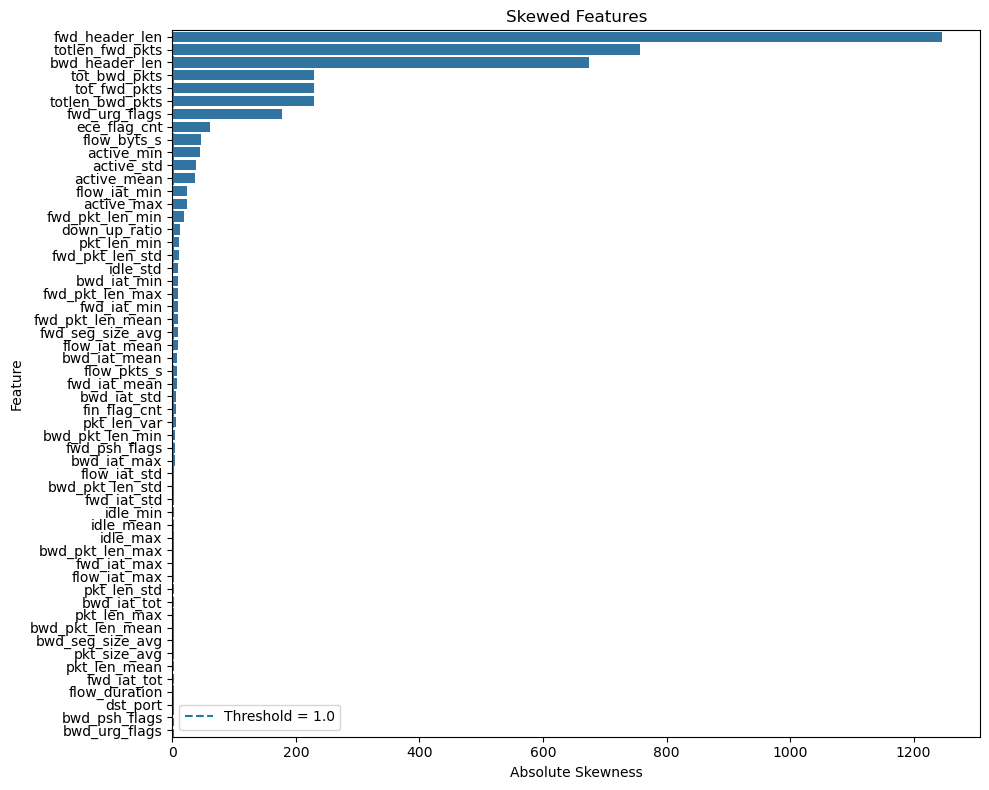

In [30]:
#Use numeric features only
num_df = (
    train_df
    .drop(columns=["label", "multi_label"], errors="ignore")
    .select_dtypes(include=np.number)
)

#exclude binary_label
num_df = num_df.drop(columns=["binary_label"], errors="ignore")

#Calculate Skewness
skewness = num_df.skew()

skew_df = pd.DataFrame({
    "feature": skewness.index,
    "skewness": skewness.values,
    "abs_skewness": skewness.abs().values
})

skew_df = skew_df.sort_values(
    "abs_skewness",
    ascending=False
)

#Features that require transformation
threshold = 1.0

transform_features = skew_df[
    skew_df["abs_skewness"] > threshold
]

print(f"\nTotal Features: {len(skew_df)}")
print(f"Need Transformation: {len(transform_features)}")

features_to_transform = transform_features["feature"].tolist()

print(features_to_transform)

#Skewness Plot
plt.figure(figsize=(10, 8))

sns.barplot(
    data=skew_df,
    x="abs_skewness",
    y="feature"
)

plt.axvline(
    threshold,
    linestyle="--",
    label=f"Threshold = {threshold}"
)

plt.title("Skewed Features")
plt.xlabel("Absolute Skewness")
plt.ylabel("Feature")
plt.legend()

plt.tight_layout()
plt.show()

##### Skewness Graph of CSE-CIC-IDS2018


Total Features: 55
Need Transformation: 53
['flow_iat_mean', 'fwd_iat_mean', 'idle_min', 'pkt_len_var', 'fwd_iat_tot', 'flow_duration', 'idle_max', 'idle_std', 'idle_mean', 'flow_iat_std', 'fwd_iat_std', 'flow_iat_min', 'fwd_iat_min', 'fwd_iat_max', 'flow_iat_max', 'totlen_fwd_pkts', 'tot_bwd_pkts', 'bwd_header_len', 'totlen_bwd_pkts', 'down_up_ratio', 'flow_byts_s', 'tot_fwd_pkts', 'fwd_header_len', 'fwd_urg_flags', 'active_min', 'active_std', 'active_mean', 'active_max', 'bwd_iat_min', 'fin_flag_cnt', 'fwd_pkt_len_min', 'bwd_iat_mean', 'flow_pkts_s', 'pkt_len_min', 'fwd_seg_size_avg', 'fwd_pkt_len_mean', 'bwd_iat_std', 'bwd_iat_max', 'fwd_pkt_len_max', 'fwd_psh_flags', 'pkt_len_mean', 'bwd_seg_size_avg', 'bwd_pkt_len_mean', 'pkt_size_avg', 'bwd_iat_tot', 'fwd_pkt_len_std', 'bwd_pkt_len_min', 'pkt_len_max', 'dst_port', 'pkt_len_std', 'bwd_pkt_len_max', 'ece_flag_cnt', 'bwd_pkt_len_std']


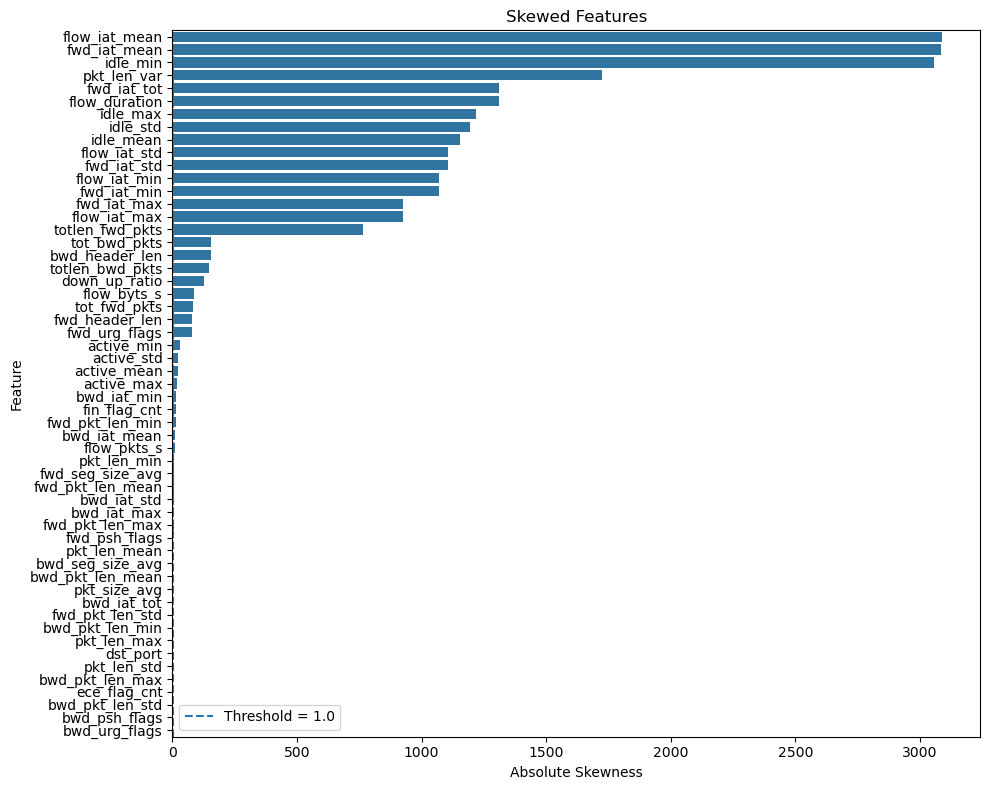

In [31]:
#Use numeric features only
num_df = (
    test1_df
    .drop(columns=["label", "multi_label"], errors="ignore")
    .select_dtypes(include=np.number)
)

#exclude binary_label
num_df = num_df.drop(columns=["binary_label"], errors="ignore")

#Calculate Skewness
skewness = num_df.skew()

skew_df = pd.DataFrame({
    "feature": skewness.index,
    "skewness": skewness.values,
    "abs_skewness": skewness.abs().values
})

skew_df = skew_df.sort_values(
    "abs_skewness",
    ascending=False
)

#Features that require transformation
threshold = 1.0

transform_features = skew_df[
    skew_df["abs_skewness"] > threshold
]

print(f"\nTotal Features: {len(skew_df)}")
print(f"Need Transformation: {len(transform_features)}")

features_to_transform = transform_features["feature"].tolist()

print(features_to_transform)

#Skewness Plot
plt.figure(figsize=(10, 8))

sns.barplot(
    data=skew_df,
    x="abs_skewness",
    y="feature"
)

plt.axvline(
    threshold,
    linestyle="--",
    label=f"Threshold = {threshold}"
)

plt.title("Skewed Features")
plt.xlabel("Absolute Skewness")
plt.ylabel("Feature")
plt.legend()

plt.tight_layout()
plt.show()

##### Skewness Graph of UNSW-NB15


Total Features: 55
Need Transformation: 47
['bwd_iat_min', 'flow_iat_min', 'fwd_iat_min', 'idle_std', 'totlen_fwd_pkts', 'active_min', 'down_up_ratio', 'active_std', 'active_mean', 'flow_iat_mean', 'active_max', 'bwd_iat_mean', 'fwd_iat_mean', 'bwd_iat_std', 'flow_iat_std', 'fwd_iat_std', 'tot_fwd_pkts', 'idle_min', 'idle_mean', 'idle_max', 'bwd_iat_max', 'flow_iat_max', 'fwd_iat_max', 'flow_byts_s', 'fwd_psh_flags', 'fwd_iat_tot', 'flow_duration', 'flow_pkts_s', 'bwd_iat_tot', 'fwd_header_len', 'pkt_len_min', 'fwd_pkt_len_min', 'totlen_bwd_pkts', 'tot_bwd_pkts', 'bwd_pkt_len_min', 'bwd_header_len', 'fwd_seg_size_avg', 'fwd_pkt_len_mean', 'fwd_pkt_len_std', 'fwd_pkt_len_max', 'pkt_size_avg', 'pkt_len_mean', 'bwd_pkt_len_mean', 'bwd_seg_size_avg', 'pkt_len_var', 'bwd_pkt_len_std', 'dst_port']


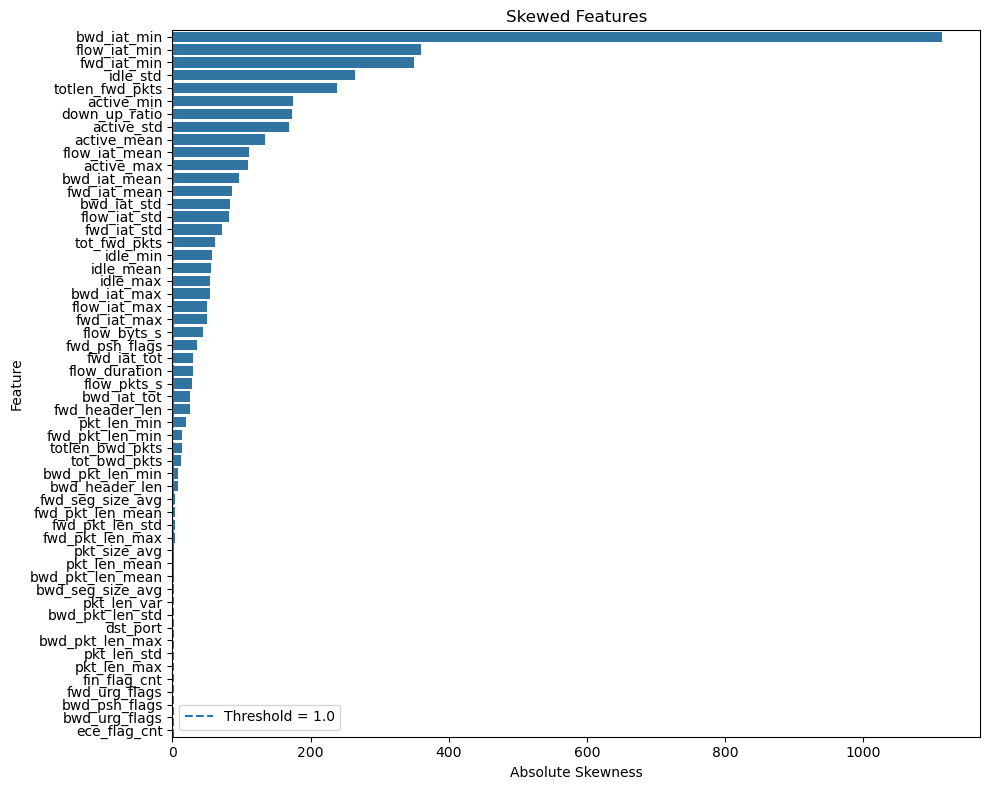

In [32]:
#Use numeric features only
num_df = (
    test2_df
    .drop(columns=["label", "multi_label"], errors="ignore")
    .select_dtypes(include=np.number)
)

#exclude binary_label
num_df = num_df.drop(columns=["binary_label"], errors="ignore")

#Calculate Skewness
skewness = num_df.skew()

skew_df = pd.DataFrame({
    "feature": skewness.index,
    "skewness": skewness.values,
    "abs_skewness": skewness.abs().values
})

skew_df = skew_df.sort_values(
    "abs_skewness",
    ascending=False
)

#Features that require transformation
threshold = 1.0

transform_features = skew_df[
    skew_df["abs_skewness"] > threshold
]

print(f"\nTotal Features: {len(skew_df)}")
print(f"Need Transformation: {len(transform_features)}")

features_to_transform = transform_features["feature"].tolist()

print(features_to_transform)

#Skewness Plot
plt.figure(figsize=(10, 8))

sns.barplot(
    data=skew_df,
    x="abs_skewness",
    y="feature"
)

plt.axvline(
    threshold,
    linestyle="--",
    label=f"Threshold = {threshold}"
)

plt.title("Skewed Features")
plt.xlabel("Absolute Skewness")
plt.ylabel("Feature")
plt.legend()

plt.tight_layout()
plt.show()

#### Training the Supervised Learning Models

We will use train CICIDS2017 dataset (100%) and test it on CSE-CIC-IDS2018 (100%) and UNSW-NB15 (100%).
1. Random Forest
2. XG Boost
3. Deep Neural Network

Binary Labels:   
1. 0 → Benign
2. 1 → Attack

Since our purpose is to analyze which model performs better in predicting the attacks, we have set our target to 'binary_label'.

In [37]:
# Dropping columns
DROP_COLS = ['label', 'binary_label', 'multi_label']

# CICIDS2017 Training dataset
X_train_df = train_df.drop(columns=DROP_COLS)

# Save feature names (only once from the training set)
feature_names = X_train_df.columns.tolist()

X_train = X_train_df.to_numpy(dtype=np.float32)
y_train = train_df['binary_label'].to_numpy(dtype=np.int8)

# Free memory
del X_train_df
gc.collect()

# CSE-CIC-IDS2018 Test1 dataset
X_test1_df = test1_df.drop(columns=DROP_COLS)

X_test1 = X_test1_df.to_numpy(dtype=np.float32)
y_test1 = test1_df['binary_label'].to_numpy(dtype=np.int8)

# Free memory
del X_test1_df
gc.collect()

# UNSW-NB15 Test2 dataset
X_test2_df = test2_df.drop(columns=DROP_COLS)

X_test2 = X_test2_df.to_numpy(dtype=np.float32)
y_test2 = test2_df['binary_label'].to_numpy(dtype=np.int8)

# Free memory
del X_test2_df
gc.collect()

0

In [38]:
# No SMOTE and Scaling for Random Forest & XGBoost

X_train_tree = X_train
X_test1_tree = X_test1
X_test2_tree = X_test2

y_train_tree = y_train
y_test1_tree = y_test1
y_test2_tree = y_test2


# Deep Neural Network (Scaling Only)

scaler = RobustScaler()

# Fit only on training data
X_train_dnn = scaler.fit_transform(X_train)

# Transform test datasets
X_test1_dnn = scaler.transform(X_test1)
X_test2_dnn = scaler.transform(X_test2)

y_train_dnn = y_train
y_test1_dnn = y_test1
y_test2_dnn = y_test2

# Free memory if the original arrays are no longer needed
del X_train, X_test1, X_test2
gc.collect()

0

#### Training the Supervised Learning Models

##### Function to evaluate the models for binary labels

In [95]:
def evaluate_model(name, model, X_test, y_test, dataset_name, is_keras=False):

    if is_keras:
        y_prob = model.predict(X_test, verbose=0).ravel()
        y_pred = (y_prob >= 0.5).astype(int)
    else:
        y_pred = model.predict(X_test)
        if hasattr(model, "predict_proba"):
            y_prob = model.predict_proba(X_test)[:, 1]
        else:
            y_prob = model.decision_function(X_test)
            
    # Evaluation metrics
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, zero_division=0)
    recall = recall_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0) #Focuses on how well the model performs in identifying Attacks.
    f1_macro = f1_score(y_test, y_pred, average="macro", zero_division=0) #Shows the overall performance of detection
    mcc = matthews_corrcoef(y_test, y_pred)  #Mathews Correlation Coefficient penalizes biased predictions and handles class imbalance better. Better evaluation metric than F1 score in terms of detecting Attack vs Benign
    auc = roc_auc_score(y_test, y_prob)

    # Print results
    print(f"{name} → {dataset_name}")
    print("*" * 30)
    print(f"Accuracy      : {accuracy:.4f}")
    print(f"Precision     : {precision:.4f}")
    print(f"Recall        : {recall:.4f}")
    print(f"F1-score      : {f1:.4f}")
    print(f"Macro F1      : {f1_macro:.4f}")
    print(f"MCC           : {mcc:.4f}")
    print(f"ROC-AUC       : {auc:.4f}")
    print()
    print(classification_report(
        y_test, y_pred,
        target_names=['Benign', 'Attack']
    ))

    #Confusion matrix
    cm   = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(cm, display_labels=['Benign', 'Attack'])
    disp.plot(cmap="Blues")
    plt.title(f"{name} — {dataset_name}")
    plt.tight_layout()
    plt.show()

    return {
        "Model": name,
        "Test Dataset": dataset_name,
        "Accuracy": round(accuracy, 4),
        "Precision": round(precision, 4),
        "Recall": round(recall, 4),
        "F1-score": round(f1, 4),
        "Macro F1": round(f1_macro, 4),
        "ROC-AUC": round(auc, 4),
        "MCC": round(mcc, 4),
    }

In [ ]:
#TUNING SUBSET

TUNING_SIZE = 300000

X_tune, _, y_tune, _ = train_test_split(
    X_train_tree,
    y_train_tree,
    train_size=TUNING_SIZE,
    stratify=y_train_tree,
    random_state=42
)

X_tune_train, X_tune_val, y_tune_train, y_tune_val = train_test_split(
    X_tune,
    y_tune,
    test_size=0.20,
    stratify=y_tune,
    random_state=42
)

print("Tuning training shape:", X_tune_train.shape)
print("Tuning validation shape:", X_tune_val.shape)

##### Training Random Forest

In [89]:
# OPTUNA - RANDOM FOREST (F1 OPTIMIZATION)

def rf_objective(trial):

    params = {
        "n_estimators": trial.suggest_int(
            "n_estimators", 100, 300, step=50
        ),

        "max_depth": trial.suggest_int(
            "max_depth", 6, 10, step=2
        ),

        "min_samples_split": trial.suggest_int(
            "min_samples_split", 2, 6, step=2
        ),

        "min_samples_leaf": trial.suggest_int(
            "min_samples_leaf", 2, 6, step=2
        ),

        "max_features": trial.suggest_categorical(
            "max_features",
            ["sqrt", "log2"]
        ),

        "class_weight": trial.suggest_categorical(
            "class_weight",
            ["balanced", "balanced_subsample"]
        ),

        "bootstrap": True,
        "criterion": "gini",
        "n_jobs": -1,
        "random_state": 42
    }

    model = RandomForestClassifier(**params)

    model.fit(
        X_tune_train,
        y_tune_train
    )

    y_pred = model.predict(X_tune_val)

    # F1-score for Attack class
    f1 = f1_score(
        y_tune_val,
        y_pred,
        zero_division=0
    )

    return f1

In [90]:
# CREATE RANDOM FOREST OPTUNA STUDY

rf_study = optuna.create_study(
    direction="maximize",
    study_name="RandomForest_F1"
)

for _ in tqdm(range(50), desc="Optuna RF Trials"):
    rf_study.optimize(
        rf_objective,
        n_trials=1,
        n_jobs=1,
        show_progress_bar=False
    )

print("\nBest Random Forest F1:")
print(round(rf_study.best_value, 4))

print("\nBest Random Forest parameters:")
print(rf_study.best_params)

[I 2026-08-15 12:05:07,434] A new study created in memory with name: RandomForest_F1


Optuna RF Trials:   0%|          | 0/50 [00:00<?, ?it/s]

[I 2026-08-15 12:05:29,933] Trial 0 finished with value: 0.990416585175044 and parameters: {'n_estimators': 100, 'max_depth': 10, 'min_samples_split': 2, 'min_samples_leaf': 4, 'max_features': 'sqrt', 'class_weight': 'balanced_subsample'}. Best is trial 0 with value: 0.990416585175044.
[I 2026-08-15 12:06:15,112] Trial 1 finished with value: 0.9906103286384976 and parameters: {'n_estimators': 250, 'max_depth': 10, 'min_samples_split': 6, 'min_samples_leaf': 4, 'max_features': 'sqrt', 'class_weight': 'balanced_subsample'}. Best is trial 1 with value: 0.9906103286384976.
[I 2026-08-15 12:06:42,674] Trial 2 finished with value: 0.9853228962818004 and parameters: {'n_estimators': 150, 'max_depth': 8, 'min_samples_split': 2, 'min_samples_leaf': 6, 'max_features': 'sqrt', 'class_weight': 'balanced_subsample'}. Best is trial 1 with value: 0.9906103286384976.
[I 2026-08-15 12:07:07,894] Trial 3 finished with value: 0.9895726244676164 and parameters: {'n_estimators': 150, 'max_depth': 10, 'min_


Best Random Forest F1:
0.991

Best Random Forest parameters:
{'n_estimators': 300, 'max_depth': 10, 'min_samples_split': 2, 'min_samples_leaf': 2, 'max_features': 'sqrt', 'class_weight': 'balanced_subsample'}


In [91]:
# FINAL RANDOM FOREST

best_rf_params = rf_study.best_params.copy()

best_rf_params.update({
    "bootstrap": True,
    "criterion": "gini",
    "n_jobs": -1,
    "random_state": 42
})

rf_final = RandomForestClassifier(
    **best_rf_params
)

print("Training final Random Forest...")

rf_final.fit(
    X_train_tree,
    y_train_tree
)

print("Final Random Forest training completed.")

Training final Random Forest...
Final Random Forest training completed.


Storing the results for models

In [92]:
results = []

##### Random Forest Evaluation

In [94]:
results.append(evaluate_model("Random Forest", rf_final, X_test1_tree, y_test1_tree, "CSE-CIC-IDS2018"))
results.append(evaluate_model("Random Forest", rf_final, X_test2_tree, y_test2_tree, "UNSW-NB15"))

MemoryError: Unable to allocate 207. MiB for an array with shape (13549591, 1, 2) and data type float64

##### Training XGBoost

In [ ]:
# OPTUNA - XGBOOST (F1 OPTIMIZATION)

# Calculate scale_pos_weight
neg = (y_train_tree == 0).sum()
pos = (y_train_tree == 1).sum()

scale_pos_weight = neg / pos

def xgb_objective(trial):

    params = {
        "n_estimators": trial.suggest_int(
            "n_estimators", 100, 300, step=50
        ),

        "max_depth": trial.suggest_int(
            "max_depth", 4, 10
        ),

        "learning_rate": trial.suggest_float(
            "learning_rate", 0.01, 0.1,   log=True
        ),

        "subsample": trial.suggest_float(
            "subsample", 0.6, 1.0
        ),

        "colsample_bytree": trial.suggest_float(
            "colsample_bytree", 0.6, 1.0
        ),

        "scale_pos_weight": scale_pos_weight,
        "objective": "binary:logistic",
        "eval_metric": "logloss",
        "tree_method": "hist",
        "random_state": 42,
        "n_jobs": -1
    }

    model = XGBClassifier(**params)

    model.fit(
        X_tune_train,
        y_tune_train
    )

    y_pred = model.predict(X_tune_val)

    # F1-score for Attack class
    f1 = f1_score(
        y_tune_val,
        y_pred,
        zero_division=0
    )

    return f1

In [ ]:
# CREATE XGBOOST OPTUNA STUDY

xgb_study = optuna.create_study(
    direction="maximize",
    study_name="XGBoost_F1"
)

for _ in tqdm(range(50), desc="Optuna XGBoost Trials"):
    xgb_study.optimize(
        xgb_objective,
        n_trials=1,
        n_jobs=-1,
        show_progress_bar=False
    )

print("\nBest XGBoost F1:")
print(round(xgb_study.best_value, 4))

print("\nBest XGBoost parameters:")
print(xgb_study.best_params)

In [ ]:
# FINAL XGBOOST MODEL

best_xgb_params = xgb_study.best_params.copy()

best_xgb_params.update({
    "objective": "binary:logistic",
    "eval_metric": "logloss",
    "tree_method": "hist",
    "random_state": 42,
    "n_jobs": -1
})

xgb_final = XGBClassifier(
    **best_xgb_params
)

print("Training final XGBoost...")

xgb_final.fit(
    X_train_tree,
    y_train_tree
)

print("Final XGBoost training completed.")

##### XGBoost Evaluation

In [ ]:
results.append(evaluate_model("XGBoost", xgb_final, X_test1_tree, y_test1_tree, "CSE-CIC-IDS2018"))
results.append(evaluate_model("XGBoost", xgb_final, X_test2_tree, y_test2_tree, "UNSW-NB15"))

##### Training Deep Neural Network

In [56]:
# DNN TUNING SUBSET

TUNING_SIZE = 300000

X_dnn_tune, _, y_dnn_tune, _ = train_test_split(
    X_train_dnn,
    y_train_dnn,
    train_size=TUNING_SIZE,
    stratify=y_train_dnn,
    random_state=42
)

X_dnn_tune_train, X_dnn_tune_val, y_dnn_tune_train, y_dnn_tune_val = train_test_split(
    X_dnn_tune,
    y_dnn_tune,
    test_size=0.20,
    stratify=y_dnn_tune,
    random_state=42
)

print("DNN tuning training shape:", X_dnn_tune_train.shape)
print("DNN tuning validation shape:", X_dnn_tune_val.shape)

DNN tuning training shape: (240000, 55)
DNN tuning validation shape: (60000, 55)


In [57]:
# OPTUNA - DNN (F1 OPTIMIZATION)

def dnn_objective(trial):

    # Hyperparameters
    n_layers = trial.suggest_int(
        "n_layers", 2, 4
    )

    units = trial.suggest_categorical(
        "units",
        [64, 128, 256, 512]
    )

    dropout_rate = trial.suggest_float(
        "dropout_rate", 0.1, 0.5
    )

    learning_rate = trial.suggest_float(
        "learning_rate", 1e-4, 1e-2, log=True
    )

    batch_size = trial.suggest_categorical(
        "batch_size",
        [512, 1024, 2048, 4096]
    )

    # Build DNN
    model = keras.Sequential()

    model.add(
        keras.layers.Input(
            shape=(X_dnn_tune_train.shape[1],)
        )
    )

    for _ in range(n_layers):

        model.add(
            keras.layers.Dense(
                units,
                activation="relu"
            )
        )

        model.add(
            keras.layers.Dropout(
                dropout_rate
            )
        )

    model.add(
        keras.layers.Dense(
            1,
            activation="sigmoid"
        )
    )

    # Compile
    model.compile(
        optimizer=keras.optimizers.Adam(
            learning_rate=learning_rate
        ),
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )

    # Train
    model.fit(
        X_dnn_tune_train,
        y_dnn_tune_train,
        validation_data=(
            X_dnn_tune_val,
            y_dnn_tune_val
        ),
        epochs=20,
        batch_size=batch_size,
        verbose=0
    )

    # Predictions
    y_prob = model.predict(
        X_dnn_tune_val,
        verbose=0
    ).ravel()

    y_pred = (
        y_prob >= 0.5
    ).astype(int)

    # Attack-class F1
    f1 = f1_score(
        y_dnn_tune_val,
        y_pred,
        zero_division=0
    )

    keras.backend.clear_session()

    return f1

In [58]:
# CREATE DNN OPTUNA STUDY

dnn_study = optuna.create_study(
    direction="maximize",
    study_name="DNN_F1"
)

for _ in tqdm(range(50), desc="Optuna DNN Trials"):
    dnn_study.optimize(
        dnn_objective,
        n_trials=1,
        n_jobs=-1,
        show_progress_bar=False
    )
print("\nBest DNN F1:")
print(round(dnn_study.best_value, 4))

print("\nBest DNN parameters:")
print(dnn_study.best_params)

[I 2026-08-15 00:42:18,955] A new study created in memory with name: DNN_F1


  0%|          | 0/30 [00:00<?, ?it/s]


[I 2026-08-15 00:42:57,391] Trial 0 finished with value: 0.2378677395021373 and parameters: {'n_layers': 3, 'units': 64, 'dropout_rate': 0.3533673422719864, 'learning_rate': 0.0001624273570747701, 'batch_size': 4096}. Best is trial 0 with value: 0.2378677395021373.
[I 2026-08-15 00:44:12,742] Trial 1 finished with value: 0.2896563257797475 and parameters: {'n_layers': 2, 'units': 64, 'dropout_rate': 0.3645057884139328, 'learning_rate': 0.00048562431810954086, 'batch_size': 512}. Best is trial 1 with value: 0.2896563257797475.
[I 2026-08-15 00:49:24,232] Trial 2 finished with value: 0.6496513616629391 and parameters: {'n_layers': 4, 'units': 512, 'dropout_rate': 0.17944720923301205, 'learning_rate': 0.001116621148356818, 'batch_size': 512}. Best is trial 2 with value: 0.6496513616629391.
[I 2026-08-15 00:50:37,300] Trial 3 finished with value: 0.6259957514604355 and parameters: {'n_layers': 2, 'units': 512, 'dropout_rate': 0.2139740788660948, 'learning_rate': 0.0014274981375653184, 'ba

In [59]:
# FINAL DNN

best_dnn_params = dnn_study.best_params

n_layers = best_dnn_params["n_layers"]
units = best_dnn_params["units"]
dropout_rate = best_dnn_params["dropout_rate"]
learning_rate = best_dnn_params["learning_rate"]

dnn_final = keras.Sequential()

dnn_final.add(
    keras.layers.Input(
        shape=(X_train_dnn.shape[1],)
    )
)

for _ in range(n_layers):

    dnn_final.add(
        keras.layers.Dense(
            units,
            activation="relu"
        )
    )

    dnn_final.add(
        keras.layers.Dropout(
            dropout_rate
        )
    )

dnn_final.add(
    keras.layers.Dense(
        1,
        activation="sigmoid"
    )
)

dnn_final.compile(
    optimizer=keras.optimizers.Adam(
        learning_rate=learning_rate
    ),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

dnn_final.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 512)            │        28,672 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 512)            │       262,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 512)            │       262,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 512)            │       262,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │           513 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 817,153 (3.12 MB)

 Trainable params: 817,153 (3.12 MB)

 Non-trainable params: 0 (0.00 B)

In [60]:
# TRAIN FINAL DNN

best_batch_size = best_dnn_params["batch_size"]

print("Training final DNN...")

history_dnn = dnn_final.fit(
    X_train_dnn,
    y_train_dnn,
    validation_split=0.10,
    epochs=40,
    batch_size=best_batch_size,
    verbose=1
)

print("Final DNN training completed.")

Training final DNN...
Epoch 1/40
4395/4395 ━━━━━━━━━━━━━━━━━━━━ 149s 33ms/step - accuracy: 0.8507 - loss: 6455.4180 - val_accuracy: 0.9670 - val_loss: 0.4374
Epoch 2/40
4395/4395 ━━━━━━━━━━━━━━━━━━━━ 151s 34ms/step - accuracy: 0.9024 - loss: 0.4109 - val_accuracy: 0.9674 - val_loss: 0.5321
Epoch 3/40
4395/4395 ━━━━━━━━━━━━━━━━━━━━ 150s 34ms/step - accuracy: 0.9034 - loss: 1.4111 - val_accuracy: 0.9669 - val_loss: 0.3409
Epoch 4/40
4395/4395 ━━━━━━━━━━━━━━━━━━━━ 157s 36ms/step - accuracy: 0.9036 - loss: 2.5242 - val_accuracy: 0.9666 - val_loss: 0.3146
Epoch 5/40
4395/4395 ━━━━━━━━━━━━━━━━━━━━ 159s 36ms/step - accuracy: 0.9038 - loss: 1.9532 - val_accuracy: 0.9670 - val_loss: 0.3416
Epoch 6/40
4395/4395 ━━━━━━━━━━━━━━━━━━━━ 154s 35ms/step - accuracy: 0.9040 - loss: 1.5258 - val_accuracy: 0.9648 - val_loss: 1.5784
Epoch 7/40
4395/4395 ━━━━━━━━━━━━━━━━━━━━ 158s 36ms/step - accuracy: 0.9043 - loss: 1.0772 - val_accuracy: 0.9654 - val_loss: 1.0958
Epoch 8/40
4395/4395 ━━━━━━━━━━━━━━━━━━━━ 15

##### DNN Evaluation

Deep Neural Network → CSE-CIC-IDS2018
******************************
Accuracy      : 0.9001
Precision     : 0.4135
Recall        : 0.0005
F1-score      : 0.0010
Macro F1      : 0.4742
MCC           : 0.0114
ROC-AUC       : 0.5954

              precision    recall  f1-score   support

      Benign       0.90      1.00      0.95  12196127
      Attack       0.41      0.00      0.00   1353464

    accuracy                           0.90  13549591
   macro avg       0.66      0.50      0.47  13549591
weighted avg       0.85      0.90      0.85  13549591



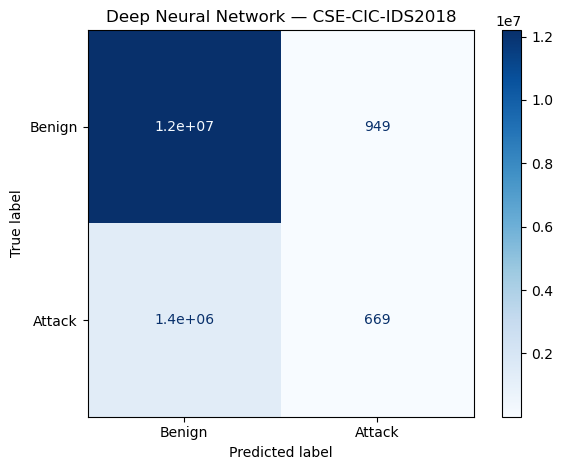

Deep Neural Network → UNSW-NB15
******************************
Accuracy      : 0.9759
Precision     : 0.8357
Recall        : 0.0794
F1-score      : 0.1449
Macro F1      : 0.5664
MCC           : 0.2532
ROC-AUC       : 0.8096

              precision    recall  f1-score   support

      Benign       0.98      1.00      0.99   3389125
      Attack       0.84      0.08      0.14     89508

    accuracy                           0.98   3478633
   macro avg       0.91      0.54      0.57   3478633
weighted avg       0.97      0.98      0.97   3478633



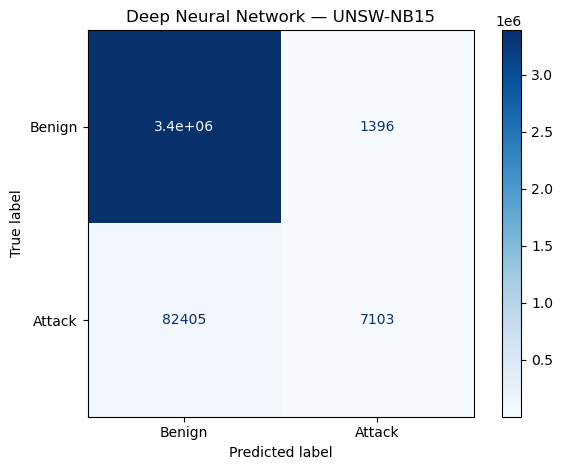

In [61]:
results.append(evaluate_model("Deep Neural Network", dnn_final, X_test1_dnn, y_test1_dnn, "CSE-CIC-IDS2018", is_keras=True))
results.append(evaluate_model("Deep Neural Network", dnn_final, X_test2_dnn, y_test2_dnn, "UNSW-NB15", is_keras=True))

##### Model Comparison

In [62]:
results_df = pd.DataFrame(results)
print(results_df)

                 Model     Test Dataset  Accuracy  Precision  Recall  \
0        Random Forest  CSE-CIC-IDS2018    0.9041     0.9608  0.0419   
1        Random Forest        UNSW-NB15    0.9743     0.5385  0.0005   
2              XGBoost  CSE-CIC-IDS2018    0.9208     0.9788  0.2115   
3              XGBoost        UNSW-NB15    0.9750     0.6780  0.0517   
4  Deep Neural Network  CSE-CIC-IDS2018    0.9001     0.4135  0.0005   
5  Deep Neural Network        UNSW-NB15    0.9759     0.8357  0.0794   

   F1-score  Macro F1  ROC-AUC     MCC  
0    0.0802    0.5148   0.8569  0.1898  
1    0.0011    0.4940   0.7570  0.0166  
2    0.3478    0.6528   0.9156  0.4353  
3    0.0962    0.5417   0.7308  0.1827  
4    0.0010    0.4742   0.5954  0.0114  
5    0.1449    0.5664   0.8096  0.2532  
